# Bias correction with a random forest

**Authors**: [Matthew Chantry](https://www.ecmwf.int/en/about/who-we-are/staff-profiles/matthew-chantry) and [Fenwick Cooper](https://www.physics.ox.ac.uk/our-people/cooperf)

*This notebook was last tested and operational on 08/05/2026. Please [report any issues](https://github.com/ecmwf-training/2026-ml-esm-training/issues).*

<!-- :::{admonition} About
:class: note, dropdown -->
This notebook was originally created for ECMWF's [MOOC on Machine Learning in Weather and Climate](https://learning.ecmwf.int/course/index.php?categoryid=1), and has been lightly updated and tested for the purposes of this course. The original notebook can be found [here](https://github.com/ecmwf-training/mooc-machine-learning-weather-climate/blob/main/tier_2/regression_decision_trees/random_forest.ipynb), and a worked example can be found [here](https://ecmwf-training.github.io/ml-examples/ex_Random_Forest_Postprocessing.html).

This example of using machine learning to model weather forecast error based on work by Fenwick Cooper funded by <a href="https://www.ifabfoundation.org/">IFAB</a>, the full study can be found <a href="https://www.ecmwf.int/en/elibrary/81297-statistical-modelling-2m-temperature-and-10m-wind-speed-forecast-errors">here</a>.
<!-- ::: -->

<!-- :::{admonition} Running this notebook
:class: tip, dropdown -->
This notebook can be run/accessed on the following free online platforms. Please note they are not officially supported by or linked with ECMWF. See [Running the notebooks](sec:running_notebooks) for more details.

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/2026-ml-esm-training/blob/m1/Postprocessing_Random_Forest.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.comecmwf-training/2026-ml-esm-training/blob/m1/Postprocessing_Random_Forest.ipynb)
[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/2026-ml-esm-training/blob/m1/Postprocessing_Random_Forest.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/2026-ml-esm-training/blob/m1/Postprocessing_Random_Forest.ipynb)
<!-- 
::: -->

## Introduction

In this example we will apply a random forest model to the ECMWF forecast of surface temperature. Specifically, we are trying to predict the difference between station observations of 2m-temperature and the corresponding forecast prediction at the nearest gridpoint to the observation location. If we can accurately predict this difference (the forecast error) we can compensate for it, making the forecast more accurate. This type of approach is called *bias correction*, which is a form of statistical post-processing.

### Random forests

Before getting into the example, let's do a quick refresher on random forests. Consider a decision tree, which behaves much like a flow chart. Decision trees partition our input data through a series of binary decisions, one variable at a time. Partitions are made, for example, by splitting on temperature >= 0 or temperature < 0. Each of these decisions creates two branches.

For each branch, there is another decision to further split the data, until some stopping criteria is met. For example, when a branch contains a minimum number of data points, or the number of decisions in the tree meets some threshold. These decisions are automatically designed to optimally partition the data.

During prediction, your input data is sorted into the partitions (nodes) created by the decision tree. For a *regression* decision tree, the output is then the value (or average of values) of the subset of the training data which belongs to this node.

A random forest is a collection of decision trees, purposely designed to differ from one another, where the final answer is the average of the prediction from all the decision trees. Random forests tend to correct the overfitting which occurs on single decision trees, and are a powerful tool, particularly for learning "tabular" data.

We will see below how this threshold-based approach creates a "blocky" prediction space, but one that performs well on many error metrics. For more info on random forests in the context of weather and climate, see Module 1.2 of the course [Machine Learning for Earth Systems Modelling (Architectures, Data and Prediction)](https://learning.ecmwf.int/course/view.php?id=99)

### In this notebook

We will explore several physically-motivated predictors. The choice of which powers or combinations of features to use could be informed by our physical understanding of the problem.

The steps we will follow are:

## Prepare your environment

The following packages are used to process and model the data:

- numpy for handling arrays and mathematical functions
- sklearn for machine learning tools
- matplotlib for plots

In [1]:
# First import the tools we will use. Where possible it is always worth using
# existing tools, even if the mathematics are simple to write down yourself.
import numpy as np
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

Before going further, we also have to download a utility function for plotting. This is contained within a [plugin](https://github.com/mchantry/climetlab-mltc-surface-observation-postprocessing) to the [Climetlab](https://climetlab.readthedocs.io/en/latest/) package, which is no longer updated. In order to avoid a dependency on this package (which can cause errors in some environments), we load the function directly from the GitHub source code.

In [2]:
# Download the raw Python file from GitHub
!wget -O utils.py https://raw.githubusercontent.com/mchantry/climetlab-mltc-surface-observation-postprocessing/master/climetlab_mltc_surface_observation_postprocessing/utils.py

# Run it in the notebook so functions are available
%run utils.py


--2026-05-08 10:05:09--  https://raw.githubusercontent.com/mchantry/climetlab-mltc-surface-observation-postprocessing/master/climetlab_mltc_surface_observation_postprocessing/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2451 (2.4K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]   2.39K  --.-KB/s    in 0s      

2026-05-08 10:05:09 (55.7 MB/s) - ‘utils.py’ saved [2451/2451]



## Load data

We will now download the dataset: this comprises 36-hour forecast errors of 2m-temperature from a ECMWF's high resolution forecast system, using station observations as the truth. Currently there are three variables in the dataset:

- `forecast_error`: the difference between the forecasted value of 2m-temperature and the observed value, in °C. This is the target variable we wish to predict.
- `time_of_day`: the local time of day, in decimal hours. Useful for diagnosing the diurnal cycle model bias. This is a "feature", a variable we will use as input to the model we train to predict the forecast error.
- `soil_temperature`: the model soil temperature, in °C. This too is a feature.

For each variable, the dataset contains over 5 million datapoints covering around 8000 weather stations around the world (not specified in the dataset).

We will load each variable separately. Notice that we have to reshape the features to 2D arrays (of one column, with each row representing a data point) for compatability with `scikit-learn`. The target variable remains a 1D row vector.

In [3]:
base_url = "https://object-store.os-api.cci1.ecmwf.int/sop/"

# load in variables one at a time (.reshape() puts in correct format for later)
forecast_error = np.genfromtxt(base_url + "forecast_error.csv", delimiter=",", skip_header=1)
soil_temperature = np.genfromtxt(base_url + "soil_temperature.csv", delimiter=",", skip_header=1).reshape(-1, 1)
time_of_day = np.genfromtxt(base_url + "time_of_day.csv", delimiter=",", skip_header=1).reshape(-1, 1)

### Task: Take a look at the data.

Use the empty code cell below to print the shapes of the three loaded arrays.

In [4]:
print('Forecast error shape:', forecast_error.shape)
print('Soil temperature shape:', soil_temperature.shape)
print('Time of day shape:', time_of_day.shape)

Forecast error shape: (5265488,)
Soil temperature shape: (5265488, 1)
Time of day shape: (5265488, 1)


Note that an important step of data preprocessing has already been carried out in the curation of the dataset. Spurious data has already been removed from the dataset based upon a range of categories, e.g. stations with inconsistent measurement locations, repeated values, or even physically  invalid numbers (>100°C). If you are starting on a new project this is a key step to clean the data.

## Prepare data

Now we can prepare the data for our model. This involves randomly splitting the data into training and testing sets, such that 80% of the data is in the training set and 20% in the testing set.

Ideally, we would like to know the geospatial location and time of our data points, because this would allow us to design our training/test sets to ensure independence (for more info, see Module 1.2 of the course [Machine Learning for Earth Systems Modelling (Architectures, Data and Prediction)](https://learning.ecmwf.int/course/view.php?id=99)). However, we don't have this information, so random sampling will be used. We will also not create a validation set because we are not exploring a hyperparameter space.

The splitting into training and test sets can be done one in one call to the `train_test_split()` function of scikit-learn.

In [5]:
# Split each of the predictands and predictors in a random train/test split.
# We use 80% of the data for training & 20% for testing
(forecast_error_train, forecast_error_test,
    time_of_day_train, time_of_day_test,
    soil_temperature_train,  soil_temperature_test) = train_test_split(forecast_error, #the variables to split
                                                                       time_of_day,
                                                                       soil_temperature,
                                                                       test_size = 0.2, #what proportion of the data to use in the test set
                                                                       random_state = 42, #set the random seed for reproducibility
                                                                      )

## Build model

Next, we train our random forest model. We begin by performing a univariate regression of the forecast error only on the time of day. In the following code, we create the `RandomForestRegressor` model object and define some hyperparameters: the number of trees in the random forest, and the maximum depth of any single tree. We then fit this model to the training data.

This can take a minute or two, so maybe time to get a coffee or a snack.

In [6]:
%%time
# The line above will time how long it takes to excute this block

# Label the input & output data, Random Forest likes a 1D vector to predict.
X = time_of_day_train
Y = forecast_error_train

# Create the Random Forest regression object
# we limit the complexity of the model by selecting a maximum depth of the trees
# you could explore how this change affects the results.
reg = RandomForestRegressor(n_estimators = 10, # The number of trees in the forest
                            max_depth = 10, # the maximum depth any tree is allowed to have
                            )

# Train the model using the data
reg.fit(X, Y)

CPU times: user 39.7 s, sys: 88.3 ms, total: 39.8 s
Wall time: 40.8 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

The model is now fitted. We will evaluate our model using root-mean-squared error (RMSE) and mean-absolute error (MAE). However we want to begin by calculating the RMSE and MAE of the existing forecasts. To do this, we compare the forecast errors with a vector of zeroes (zero being no error). The idea will be to see whether our model can improve on these scores.

In [7]:
# Our baseline is no error correction, or a correction of 0.
zero_test = 0.0*forecast_error_test

#Calculate the MAE
baseline_mae = metrics.mean_absolute_error(zero_test, forecast_error_test)
#Calculate the RMSE
baseline_rmse = np.sqrt(metrics.mean_squared_error(zero_test, forecast_error_test))

### Task: Print the baseline error metrics
Use the code cell below to print the uncorrected error metrics to the screen:

In [8]:
print('Mean Absolute Error Uncorrected:', baseline_mae)
print('Root Mean Squared Error Uncorrected:', baseline_rmse)

Mean Absolute Error Uncorrected: 1.6323756023379807
Root Mean Squared Error Uncorrected: 2.256135253978746


Can our random forest model improve this? To find out, we will generate error predictions at the times of day used in the test data, and compare with the corresponding observed errors, obtaining new RMSE and MAE values. If these MAE and RMSE are less than the baseline values, this implies that the random forest model would be able to improve the forecasts (by subtracting the resulting errors).

In [9]:
#Build our input array for the test data, then make a prediction with our model
X_test = time_of_day_test # Reshape X to be a 2D array

forecast_corrected = reg.predict(X_test)

corrected_mae = metrics.mean_absolute_error(forecast_error_test, forecast_corrected)
corrected_rmse = np.sqrt(metrics.mean_squared_error(forecast_error_test, forecast_corrected))

### Task: Print the improved model metrics
Use the code cell below to print the two error metrics for:
- The corrected forecast error
- The percentage improvement in our corrected forecast error, compared to the baseline forecast error

In [10]:
print('Mean Absolute Error Corrected:', corrected_mae)
print('Root Mean Squared Error Corrected:', corrected_rmse)

print('% Improvement MAE over raw forecast', -(corrected_mae - baseline_mae)/baseline_mae * 100 )
print('% Improvement RMSE over raw forecast', -(corrected_rmse - baseline_rmse)/baseline_rmse * 100 )

Mean Absolute Error Corrected: 1.5549685868340333
Root Mean Squared Error Corrected: 2.1648598584173366
% Improvement MAE over raw forecast 4.741985569563815
% Improvement RMSE over raw forecast 4.04565264429263


This shows that we would get an improvement of around 4% if we were to use the random forest model based on time of day to correct the forecast bias.

Now we plot the model error predictions and the observed predictions from the test set against time of day. Because the number of observations is quite large (about one million), we will not plot the observed predictions as individual points, but instead generate a density map using the `imgBufferFromVectors()` function. We'll then overlay our fitted line.

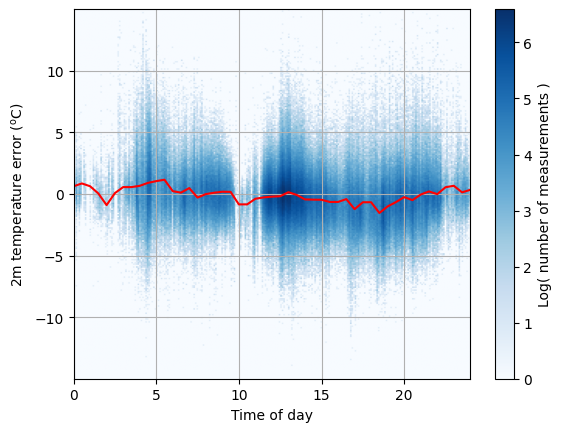

In [11]:
# Predict the outputs for all values between 0 & 24.
x = np.linspace(0, 24, 49)[...,np.newaxis]
y = reg.predict(x)

# Make a graph of the time of day against the forecast error.
# This function helps us build an image of the results
tod_buffer, ax_extent, count = imgBufferFromVectors(time_of_day_test, forecast_error_test.reshape(-1, 1),
                                                    nx=256, ny=256, extent=[],
                                                    calc_average=False)
# Plot the number of measurements at each time of day and forecast error
plt.imshow(np.log((count==0.0)+count),
           cmap='Blues', origin='lower',
           extent=ax_extent, aspect='auto')

plt.xlim([0, 24])
plt.grid()
plt.xlabel('Time of day')
plt.ylabel(r'2m temperature error ($^\mathrm{o}$C)')
cb = plt.colorbar()
cb.set_label('Log( number of measurements )')

# Line of best fit
plt.plot(x,y,'red')

plt.show()

Although the model (red line) is better than nothing (and does indeed have the potential to improve our forecasts slightly), there is still a lot of of variation which is *not* explained. Indeed, the error only seems to have a weak relationship with the time of day.

### Task: Think about it
Does this look like a sensible model? Before moving on, think about the following: The plot shows a rather complex relationship between time of day and error. Should we expect our random forest to be able to capture this complexity?

In theory, since the random forest is a non-linear model, it could capture complex variations. But this plot also very clearly illustrates that at a given time of the day, you have a large range of possible errors, and it is very unlikely that even the best random forest can predict this explosion of uncertainty.

How can we improve the results? Let's test whether another predictor can help. We will try using the soil temperature.

## Adding more predictors

Next we will add a second predictor, the model soil temperature. Let's look at how the forecast error varies with these predictors to understand how well we might expect our model to perform.

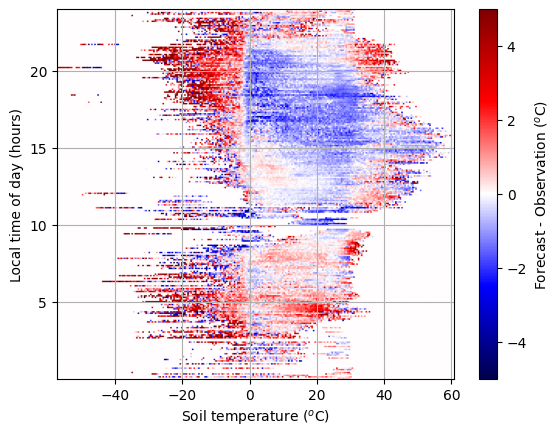

In [12]:
# Make image of the error with the new predictor
buffer, ax_extent, count = imgBufferFromVectors(soil_temperature_test,
                                                time_of_day_test,
                                                forecast_error_test.reshape(-1, 1),
                                                256, 256,
                                                extent = [],
                                                calc_average=True)
# Plot the image of the error
plt.imshow(buffer, vmin=-5, vmax=5, cmap='seismic', origin='lower',
           extent=ax_extent, aspect='auto')

plt.grid()
plt.xlabel('Soil temperature ($^o$C)')
plt.ylabel("Local time of day (hours)")
cb = plt.colorbar()
cb.set_label('Forecast - Observation ($^o$C)')

plt.show()

This plot is a heatmap of the forecast error (represented by the colour bar), plotted against the soil temperature and time of day (x and y axes, respectively). We see that forecast errors vary with both of these predictors, so we can expect our model to improve if we add soil temperature as a predictor. It also appears that there is a more discernable pattern in the forecast error, and this implies that it might more be more feasible to model it.

### Task: Train the model with two predictors
Complete the code cell below to re-train the model with these two predictors. You can use the cell where we first trained the model as inspiration, i.e. call this model `reg` again. It may once more take a minute or two to complete.

In [13]:
%%time
# Concatenate predictors into a single array
X = np.concatenate([time_of_day_train, soil_temperature_train],axis=-1)

# Target is still the forecast error
Y = forecast_error_train

# Code your solution here
# Create random forest model
reg = RandomForestRegressor(n_estimators = 10, # The number of trees in the forest
                            max_depth = 10, # the maximum depth any tree is allowed to have
                            )
# Train the model using the train sets
reg.fit(X, Y)

CPU times: user 1min, sys: 229 ms, total: 1min
Wall time: 1min 1s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

We now want to evaluate the performance of our new model. To do so, we follow the same procedure as previously: we generate predictions at the points in the test dataset, and compare the error of the random forest model with the error with respect to the zero baseline.

In [14]:
# Remind ourselves of the original errors of prediction:
zero_test = 0.0*forecast_error_test
print('Mean Absolute Error Uncorrected:', metrics.mean_absolute_error(zero_test, forecast_error_test))
print('Root Mean Squared Error Uncorrected:', np.sqrt(metrics.mean_squared_error(zero_test, forecast_error_test)))

Mean Absolute Error Uncorrected: 1.6323756023379807
Root Mean Squared Error Uncorrected: 2.256135253978746


### Task: Evaluate the model on the test data
Create a new test dataset of predictors `X_test`, by concatenating the test predictor arrays in a single array, just like before training the model. Then, make a prediction with the model called `forecast_corrected`, following the procedure we used when we evaluated the model with a single predictor a few cells ago.

In [15]:
# Code your solution here
X_test = np.concatenate([time_of_day_test, soil_temperature_test
              ],axis=-1)

forecast_corrected = reg.predict(X_test)

# Calculate the metrics
corrected_mae = metrics.mean_absolute_error(forecast_error_test, forecast_corrected)
corrected_rmse = np.sqrt(metrics.mean_squared_error(forecast_error_test, forecast_corrected))

# Print the metrics
print('Mean Absolute Error Corrected:', corrected_mae)
print('Root Mean Squared Error Corrected:', corrected_rmse)
print('% Improvement MAE over raw forecast', -(corrected_mae - baseline_mae)/baseline_mae * 100 )
print('% Improvement RMSE over raw forecast', -(corrected_rmse - baseline_rmse)/baseline_rmse * 100 )

Mean Absolute Error Corrected: 1.5287751215440604
Root Mean Squared Error Corrected: 2.119583547920482
% Improvement MAE over raw forecast 6.346608013838108
% Improvement RMSE over raw forecast 6.052460986877986


We see an improvement of ~6% just from using these two predictors. We'll also visualise the results - to do so we have to generate a grid of points over the domain and generate model predictions at those points.

In [16]:
# Run the fit model over the plot domain

# The x and y values of each point in the plot image
nx = buffer.shape[0]
ny = buffer.shape[1]
x_st = np.linspace(ax_extent[0],ax_extent[1],nx)  # Represents soil_temperature
y_tod = np.linspace(ax_extent[2],ax_extent[3],ny)  # Represents time_of_day
x_mesh = np.meshgrid(y_tod,x_st,indexing='ij')
x_mesh = np.stack(x_mesh,axis=-1).reshape((-1,2)) # Combine these predictors together to make the input array.

model_buffer = reg.predict(x_mesh).reshape(buffer.shape) #We need to reshape the output for plotting

We now generate the plots. We'll plot:

1. The observed forecast errors (as plotted previously).
2. The model-predicted forecast errors, at the points in the test set.
3. The model-predicted forecast errors over the whole domain, i.e. also at combinations of time-of-day and soil temperature that were not present in the provided dataset.

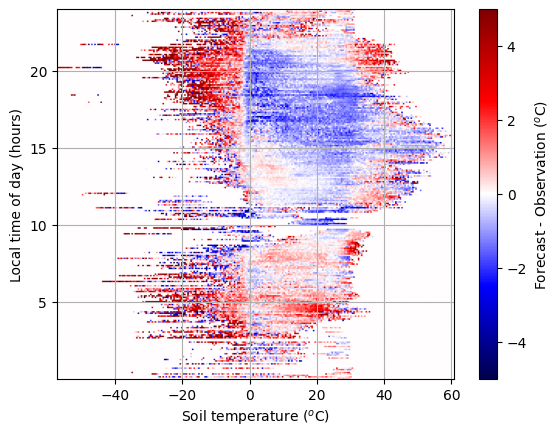

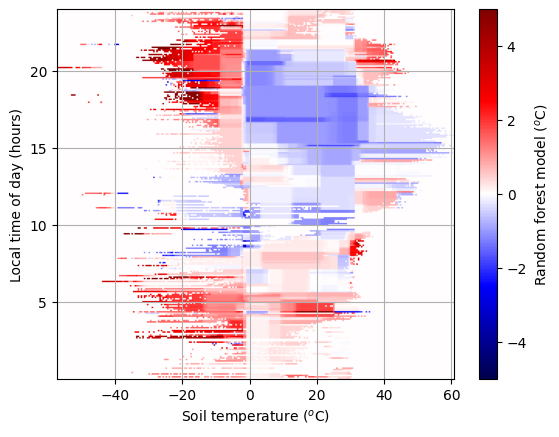

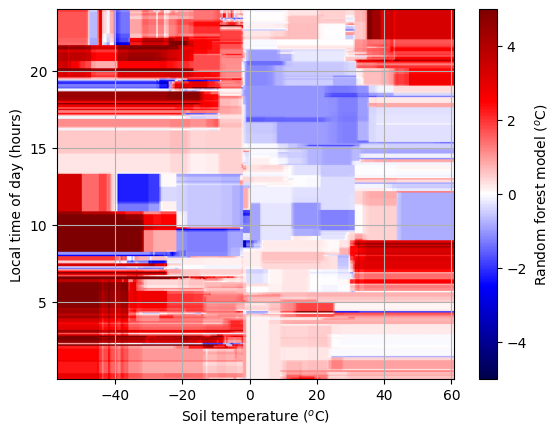

In [17]:
# Plot the image of the error
plt.imshow(buffer, vmin=-5, vmax=5, cmap='seismic', origin='lower',
           extent=ax_extent, aspect='auto')

plt.grid()
plt.xlabel('Soil temperature ($^o$C)')
plt.ylabel("Local time of day (hours)")
cb = plt.colorbar()
cb.set_label('Forecast - Observation ($^o$C)')

plt.show()

# Plot the model, only over the points where there is data in the test set.
plt.imshow((model_buffer)*(count>0), vmin=-5, vmax=5, cmap='seismic', origin='lower',
           extent=ax_extent, aspect='auto')

plt.grid()
plt.xlabel('Soil temperature ($^o$C)')
plt.ylabel("Local time of day (hours)")
cb = plt.colorbar()
cb.set_label('Random forest model ($^o$C)')

plt.show()

# Plot the model over the whole domain
plt.imshow(model_buffer, vmin=-5, vmax=5, cmap='seismic', origin='lower',
           extent=ax_extent, aspect='auto')

plt.grid()
plt.xlabel('Soil temperature ($^o$C)')
plt.ylabel("Local time of day (hours)")
cb = plt.colorbar()
cb.set_label('Random forest model ($^o$C)')

plt.show()

The model constructed with random forests indeed has slightly smaller errors throughout the plotted domain. But it clearly also has not fixed all biases, such as the cold bias in the late afternoon and early evening between 0-20C soil temperature.
You can also see that the random forest model has a complex and blocky shape. These sharp edges denote where one or more tree has a branch point. And finally, by looking at the bottom plot, you can clearly see it produces unlikely results outside of the training dataset (for example at cold soil temperatures (below -40C) around 5 AM).

### Task (optional): How would you improve this model?
Try adjusting some of the hyperparameters of the random forest model. What else could we do?